# ChEBIs present in Rhea and TCDB

This notebooks sole purpose is to higlight the difference as to what ChEBI substrates that are present in Rhea and TCDB. Note that the specificity is not taken into account. Hence, there are undubiously substrates with a lot of descendants in TCDB.

In [23]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [17]:
rhea = pd.read_csv("../Rhea/Rhea.tsv", sep="\t")
rhea_subs = set(rhea["ChEBI identifier"].str.split(';').explode().tolist())

In [10]:
def fetch_data(url):
    response = requests.get(url)
    response.raise_for_status()
    return response.text

def parse_data(substrates_txt):
    # Substrates (TCID, CHEBI ID)
    substrates_lines = substrates_txt.strip().split("\n")
    substrate_data = [[line.split("\t")[0], chebi.split(";")[0]]
                        for line in substrates_lines
                        for chebi in line.split("\t")[1].split("|")]
    
    df_substrates = pd.DataFrame(substrate_data, columns=["TCID", "CHEBI ID"])

    return df_substrates

In [13]:
tc_substrates_url = "https://www.tcdb.org/cgi-bin/substrates/getSubstrates.py"
tc_substrates_txt = fetch_data(tc_substrates_url)
df_tc_substrates = parse_data(tc_substrates_txt)

In [22]:
tc_subs = set(df_tc_substrates["CHEBI ID"].explode().tolist())

Need to ensure everything is converted to primary ChEBI IDs...

In [35]:
s2p_df = pd.read_csv("../ChEBI/s2p.tsv", sep="\t")
secondary_to_primary = dict(zip(s2p_df["Secondary_ID"], s2p_df["Primary_ID"]))
def s2p(chebi_id):
    return secondary_to_primary.get(chebi_id, chebi_id)

tc_subs1 = set([s2p(el) for el in tc_subs])
rhea_subs1 = set([s2p(el) for el in rhea_subs])

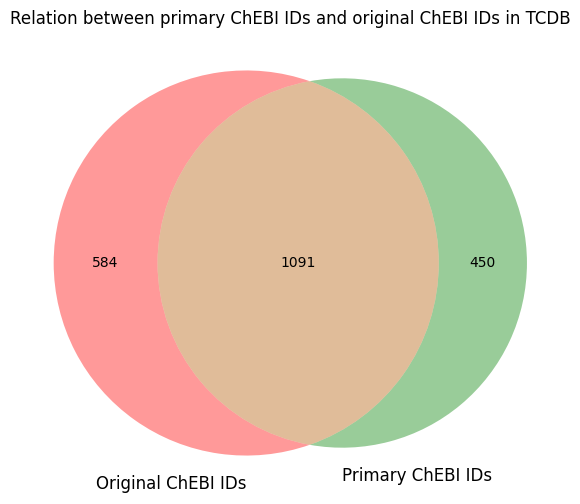

In [37]:
plt.figure(figsize=(10, 6))
venn = venn2([tc_subs, tc_subs1], ("Original ChEBI IDs", "Primary ChEBI IDs"))
plt.title("Relation between primary ChEBI IDs and original ChEBI IDs in TCDB")
plt.show()

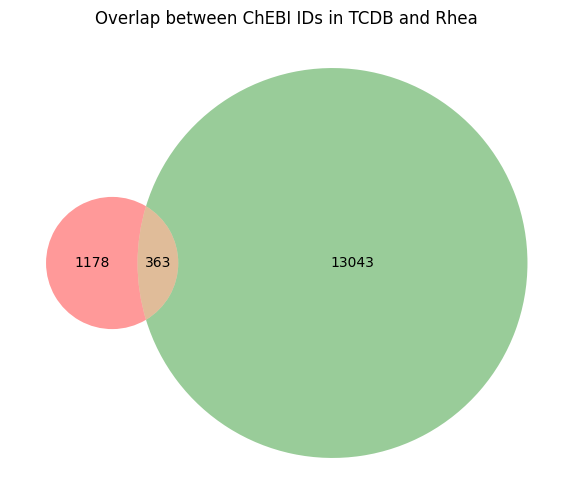

In [ ]:
plt.figure(figsize=(10, 6))
# venn = venn2([tc_subs1, rhea_subs1], ("TCDB ChEBI IDs ", "Rhea ChEBI IDs"))
venn = venn2([tc_subs1, rhea_subs1], (" ", ""))
plt.title("Overlap between ChEBI IDs in TCDB and Rhea")
plt.show()